In [53]:
import sys
sys.path.append("../../")
from src.training import helpers as tr_h
import scanpy as sc
import logging, numpy as np

adata = sc.read_h5ad("/aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-08-14-01/data.h5ad")


/home/ddalton/Data/old_home/miniconda3/envs/scgpt_2/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [ ]:

def get_top_k_most_present_genes(
    adata: sc.AnnData,
    k: int = 3501,
) -> np.array:
    """
    Filters genes based on the top `k` most present genes across samples.
    If there are more genes with the same presence, the top `k` will be selected
    based on variance as a secondary criterion.

    Parameters:
    - adata: AnnData object containing gene expression data
    - k: The number of top genes to retain based on their presence across samples

    Returns:
    - A boolean array (mask) indicating which genes to keep.
    """
    total_n_genes = adata.X.shape[1]
    total_n_samples = adata.X.shape[0]

    logging.info(f"Nº genes: {total_n_genes}, Nº samples: {total_n_samples}")

    # Step 1: Count gene presence (non-NaN and non-zero values) across samples
    count_presence = np.sum(~np.isnan(adata.X), axis=0)

    # Step 2: Sort genes by presence in descending order
    sorted_indices = np.argsort(count_presence)[::-1]

    # Step 3: Handle the case where multiple genes have the same presence
    top_k_indices = sorted_indices[:k]
    
    if k < len(sorted_indices) and count_presence[top_k_indices[-1]] == count_presence[sorted_indices[k]]:
        min_presence = count_presence[top_k_indices[-1]]

        # Step 4: Find all genes with the same presence as the cutoff
        equal_presence_indices = sorted_indices[count_presence[sorted_indices] == min_presence]

        # Step 5: If the number of equal presence genes exceeds `k`, use variance as a tie-breaker
        remaining_slots = k - np.sum(count_presence[sorted_indices[:k]] > min_presence)
        if len(equal_presence_indices) > remaining_slots:
            # Compute variance for all genes
            gene_variance = np.nanstd(adata.X, axis=0)
            
            # substitute nan values with -infinite values
            gene_variance = np.nan_to_num(gene_variance, nan=-np.inf)
            
            # Sort equal presence genes by variance in descending order
            sorted_by_variance = equal_presence_indices[np.argsort(gene_variance[equal_presence_indices])[::-1]]

            # Replace the last entries in the top `k` with highest variance genes from the tie
            top_k_indices = np.concatenate(
                [sorted_indices[count_presence[sorted_indices] > min_presence], 
                 sorted_by_variance[:remaining_slots]]
            )
        else:
            top_k_indices = sorted_indices[:k]

    # Step 6: Create a boolean mask for the top `k` genes
    mask_top_k = np.zeros(total_n_genes, dtype=bool)
    mask_top_k[top_k_indices] = True

    logging.info(f"Top {k} most present genes selected. - >= {min(count_presence[mask_top_k])}")

    return mask_top_k





mask_genes = tr_h.get_top_k_most_present_genes(
    adata, k=3501
)


In [55]:
mask_genes

array([False, False, False, ...,  True, False, False])

In [68]:
def compute_FC(adata)->np.array:
    # Subset by condition
    adata_control = adata[adata.obs["doid_id"] == "Control"]
    adata_disease = adata[adata.obs["doid_id"] != "Control"]

    # Mean expression per group (already log scale)
    mean_control = np.asarray(adata_control.X.mean(axis=0)).flatten()
    mean_disease = np.asarray(adata_disease.X.mean(axis=0)).flatten()

    # log2FC is simply difference of means
    log2fc = mean_disease - mean_control
    return log2fc


def get_top_k_fc(adata, k=3500):


    total_n_genes = adata.X.shape[1]

    # compute fc
    all_fc = []
    for dsaid in adata.obs["dsaid"].unique():
        adata_dsaid = adata[adata.obs["dsaid"] == dsaid].copy()
        fc = compute_FC(adata_dsaid)
        all_fc.append(fc)

    all_fc = np.array(all_fc)

    # compute presence/absence of counts
    count_presence = np.sum(~np.isnan(adata.X), axis=0)


    # cutoff for top 50% genes by counts
    cutoff = np.percentile(count_presence, 50)
    mask_top = count_presence >= cutoff

    # compute max abs FC per gene
    max_abs_fc = np.nanmean(np.abs(all_fc), axis=0)

    # apply mask
    gene_idx_top = np.where(mask_top)[0]
    fc_sel = max_abs_fc[mask_top]

    # pick top K
    top_local = np.argsort(fc_sel)[::-1][:k]
    selected_idx = gene_idx_top[top_local]


    # boolean mask for the top `k` genes
    mask_top_k = np.zeros(total_n_genes, dtype=bool)
    mask_top_k[selected_idx] = True

    return mask_top_k

mask_2 = get_top_k_fc(adata, k=3501)

/tmp/ipykernel_523277/2107069444.py:38: RuntimeWarning: Mean of empty slice
  max_abs_fc = np.nanmean(np.abs(all_fc), axis=0)


In [61]:
np.sum(mask_genes & mask_2)

1424

In [69]:
adata_filt_1 = adata[:, mask_genes]
adata_filt_2 = adata[:, mask_2]

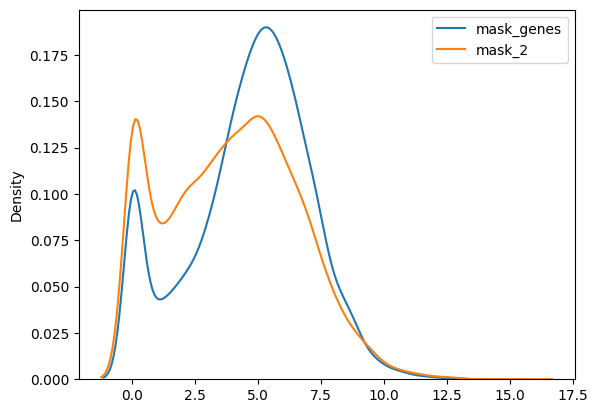

In [74]:
import seaborn as sns
import random

sns.kdeplot(random.sample(list(adata_filt_1.X.flatten()),10000), label="mask_genes")
sns.kdeplot(random.sample(list(adata_filt_2.X.flatten()),10000), label="mask_2")
plt.legend()

In [63]:
# if applying this threshold how many genes are retained per sample
adata_filt = adata[:, mask_2]

# Count retained genes per sample
n_retained_genes = np.sum(~np.isnan(adata_filt.X), axis=1)

In [67]:
adata_filt.X

ArrayView([[ 7.45157571,  0.28048659,  1.92214388, ...,  1.74873998,
             1.32321518,  2.40383748],
           [ 6.31002949,  1.1917585 ,  0.71559034, ...,  2.51327267,
             1.32098239,  1.4395771 ],
           [ 6.33381613,  1.02282256,  0.69522258, ...,  2.92677719,
             2.03409986,  0.86830138],
           ...,
           [ 5.35953042,  3.04030426,  0.42666836, ...,  5.38351475,
             4.398963  ,  0.69548321],
           [10.7232234 ,  3.14110448,  2.33260977, ...,  5.23698614,
             5.16271281,  1.00668531],
           [ 9.94583277,  3.13173671,  1.76285447, ...,  5.16877103,
             4.5278615 ,  0.86184209]])

(array([3.0000e+01, 0.0000e+00, 0.0000e+00, 1.5000e+01, 0.0000e+00,
        0.0000e+00, 1.2000e+01, 0.0000e+00, 4.7000e+01, 3.5522e+04]),
 array([   0.,  350.,  700., 1050., 1400., 1750., 2100., 2450., 2800.,
        3150., 3500.]),
 <BarContainer object of 10 artists>)

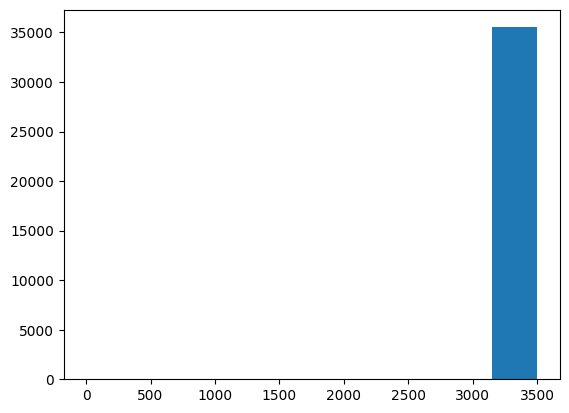

In [66]:
import matplotlib.pyplot as plt
plt.hist(n_retained_genes)

/tmp/ipykernel_523277/1539024048.py:11: RuntimeWarning: Mean of empty slice
  max_abs_fc = np.nanmean(np.abs(all_fc), axis=0)


In [52]:
mask_top_k

array([False, False,  True, ...,  True, False, False])

In [48]:
selected_idx

array([ 7153,  7154,  7168, ...,  8026, 14054, 13628])

In [ ]:
# Step 1: Count gene presence (non-NaN and non-zero values) across samples
count_presence = np.sum(~np.isnan(adata.X), axis=0)

# Step 2: Sort genes by presence in descending order
sorted_indices = np.argsort(count_presence)[::-1]



In [ ]:
top_50_present_thr = np.percentile(count_presence, 50, axis=0)

mask_top_50_present = count_presence >= top_50_present_thr

# select top k genes with higher absolute values for fold change


In [ ]:
def get_top_k_most_present_genes(
    adata: AnnData,
    k: int = 3501,
) -> np.array:
    """
    Filters genes based on the top `k` most present genes across samples.
    If there are more genes with the same presence, the top `k` will be selected
    based on variance as a secondary criterion.

    Parameters:
    - adata: AnnData object containing gene expression data
    - k: The number of top genes to retain based on their presence across samples

    Returns:
    - A boolean array (mask) indicating which genes to keep.
    """
    total_n_genes = adata.X.shape[1]
    total_n_samples = adata.X.shape[0]

    logging.info(f"Nº genes: {total_n_genes}, Nº samples: {total_n_samples}")

    # Step 1: Count gene presence (non-NaN and non-zero values) across samples
    count_presence = np.sum(~np.isnan(adata.X), axis=0)

    # Step 2: Sort genes by presence in descending order
    sorted_indices = np.argsort(count_presence)[::-1]

    # Step 3: Handle the case where multiple genes have the same presence
    top_k_indices = sorted_indices[:k]
    
    if k < len(sorted_indices) and count_presence[top_k_indices[-1]] == count_presence[sorted_indices[k]]:
        min_presence = count_presence[top_k_indices[-1]]

        # Step 4: Find all genes with the same presence as the cutoff
        equal_presence_indices = sorted_indices[count_presence[sorted_indices] == min_presence]

        # Step 5: If the number of equal presence genes exceeds `k`, use variance as a tie-breaker
        remaining_slots = k - np.sum(count_presence[sorted_indices[:k]] > min_presence)
        if len(equal_presence_indices) > remaining_slots:
            # Compute variance for all genes
            gene_variance = np.nanstd(adata.X, axis=0)
            
            # substitute nan values with -infinite values
            gene_variance = np.nan_to_num(gene_variance, nan=-np.inf)
            
            # Sort equal presence genes by variance in descending order
            sorted_by_variance = equal_presence_indices[np.argsort(gene_variance[equal_presence_indices])[::-1]]

            # Replace the last entries in the top `k` with highest variance genes from the tie
            top_k_indices = np.concatenate(
                [sorted_indices[count_presence[sorted_indices] > min_presence], 
                 sorted_by_variance[:remaining_slots]]
            )
        else:
            top_k_indices = sorted_indices[:k]

    # Step 6: Create a boolean mask for the top `k` genes
    mask_top_k = np.zeros(total_n_genes, dtype=bool)
    mask_top_k[top_k_indices] = True

    logging.info(f"Top {k} most present genes selected. - >= {min(count_presence[mask_top_k])}")

    return mask_top_k

